# Analysis of the AGP in different cases with 1st order phase transition

#### Imports

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from src.annealing_utils import (
    get_driver_hamiltonian,
    get_longitudinal_hamiltonian,
    computational_basis,
)
from src.schedule_utils import SchedulerModel, Schedule
from ManyBodyQutip.qutip_class import SpinOperator
from src.utils import Sector
from src.optimalcontrol_magic_constrain_utils import (
    JaxSchedulerModelMagic,
    JaxTrainerMagic,
)
import pickle
from src.annealing_utils import compute_exact_AGP
from src.annealing_utils import agp_osd

### Maximum weighted independent set

#### Problem Hamiltonian parameters

In [4]:
import numpy as np
from src.annealing_utils import get_longitudinal_hamiltonian, get_driver_hamiltonian


def mwis_jij_hz(n0, n1, dW, Jzz):
    n = n0 + n1
    G0 = list(range(n0))
    G1 = list(range(n0, n0 + n1))

    jij = np.zeros((n, n))
    for i in G0:
        for j in G1:
            jij[i, j] = Jzz
            jij[j, i] = Jzz

    h0 = n1 * Jzz - 2 * (1 + dW) / n0
    h1 = n0 * Jzz - 2 / n1

    hz = np.zeros(n)
    for i in G0:
        hz[i] = +h0
    for j in G1:
        hz[j] = +h1

    return jij, hz

Hyperparameters

In [24]:
# ── Example: n0=2, n1=3, matching the paper's 5-qubit instance ───────────────
n0, n1 = 2, 3
n_qubits = n0 + n1
dW = 0.1  # small weight imbalance → perturbative crossing
Jzz = 5.33  # edge penalty (closed-system example in paper)

jij, hz = mwis_jij_hz(n0, n1, dW, Jzz)

print("Jij matrix:")
print(np.round(jij, 3))
print("\nhz vector:")
print(np.round(hz, 3))

Jij matrix:
[[0.   0.   5.33 5.33 5.33]
 [0.   0.   5.33 5.33 5.33]
 [5.33 5.33 0.   0.   0.  ]
 [5.33 5.33 0.   0.   0.  ]
 [5.33 5.33 0.   0.   0.  ]]

hz vector:
[14.89  14.89   9.993  9.993  9.993]


Hamiltonians

In [25]:
# ── Feed into your src functions ─────────────────────────────────────────────
nqubits = n0 + n1
target_hamiltonian = get_longitudinal_hamiltonian(jij, hz)  # sparse scipy matrix
driver_hamiltonian = get_driver_hamiltonian(nqubits=nqubits)  # sparse scipy matrix

Energy Levels of Annealing Evolution

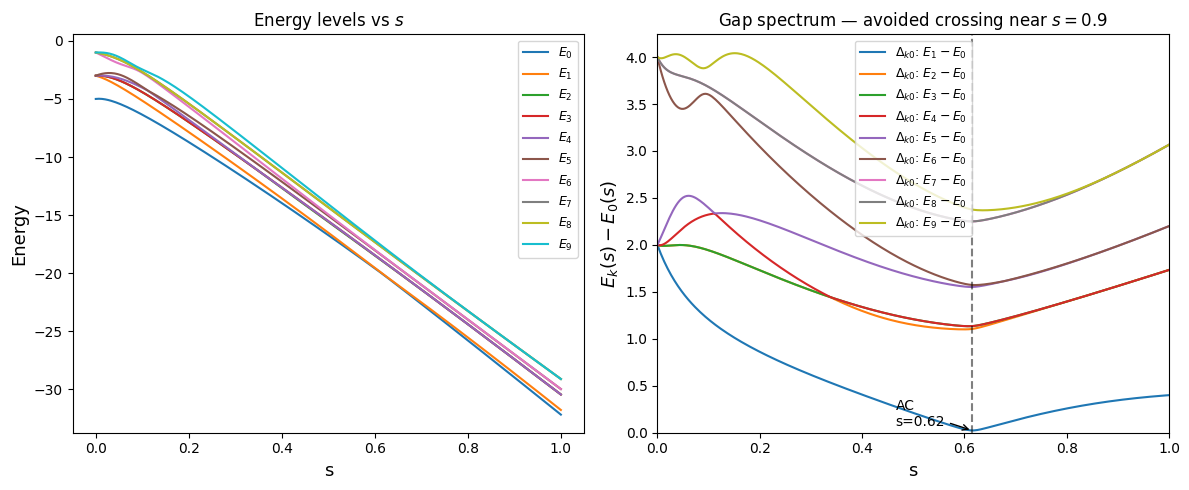

Minimum gap Δ₁₀ = 0.024163 at s = 0.615


In [42]:
from scipy.sparse.linalg import eigsh

# --- Sweep s ---
grid_size = 300
n_levels = 10
s_vals = np.linspace(0, 1, grid_size)
spectra = np.zeros((len(s_vals), n_levels))
psi_history = []

for idx, s in enumerate(s_vals):
    total_hamiltonian = (1 - s) * driver_hamiltonian + s * target_hamiltonian
    vals, psis = eigsh(total_hamiltonian, k=n_levels, which="SA")
    order = np.argsort(vals)
    # (dim, n_eigs), sorted by energy
    spectra[idx] = np.sort(vals.real)

    psi_history.append(psis[:, order[0]])

E0 = spectra[:, 0]  # ground state energy at each s

# --- Plot 1: Raw energy levels ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for k in range(n_levels):
    ax.plot(s_vals, spectra[:, k], label=f"$E_{k}$")
ax.set_xlabel("s", fontsize=13)
ax.set_ylabel("Energy", fontsize=13)
ax.set_title("Energy levels vs $s$")
ax.legend(fontsize=9)

# --- Plot 2: Gaps Δ_k0 = E_k - E_0  (what the paper plots) ---
ax = axes[1]
colors = ["C1", "C2", "C3", "C4", "C5"]
for k in range(1, n_levels):
    gap = spectra[:, k] - E0
    ax.plot(s_vals, gap, label=f"$\\Delta_{{k0}}$: $E_{k}-E_0$")

ax.set_xlabel("s", fontsize=13)
ax.set_ylabel("$E_k(s) - E_0(s)$", fontsize=13)
ax.set_title("Gap spectrum — avoided crossing near $s=0.9$")
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, None)

# Mark the minimum gap
min_gap = spectra[:, 1] - E0
s_mingap = s_vals[np.argmin(min_gap)]
ax.axvline(
    s_mingap, color="k", linestyle="--", alpha=0.5, label=f"min gap @ s={s_mingap:.2f}"
)
ax.annotate(
    f"AC\ns={s_mingap:.2f}",
    xy=(s_mingap, min_gap.min()),
    xytext=(s_mingap - 0.15, min_gap.min() + 0.05),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10,
)

plt.tight_layout()
plt.savefig("avoided_crossing.png", dpi=150)
plt.show()

print(f"Minimum gap Δ₁₀ = {min_gap.min():.6f} at s = {s_mingap:.3f}")

#### Compute the AGP for this case

Pointwise values of the AGP

[2.72064407e-36 8.96420019e-01 9.62840662e-02 2.48493489e-03
 3.47725905e-03 1.33372134e-03]
1.1170205984169927
IYIII  q=0.2661  c=7.4621+0.0000j
YIIII  q=0.2661  c=7.4621+0.0000j
IIIYI  q=0.1214  c=5.0409+0.0000j
IIYII  q=0.1214  c=5.0409+0.0000j
IIIIY  q=0.1214  c=5.0409+0.0000j
ZIYII  q=0.0129  c=1.6440+0.0000j
IZIIY  q=0.0129  c=1.6440+0.0000j
IZIYI  q=0.0129  c=1.6440+0.0000j
ZIIYI  q=0.0129  c=1.6440+0.0000j
ZIIIY  q=0.0129  c=1.6440+0.0000j


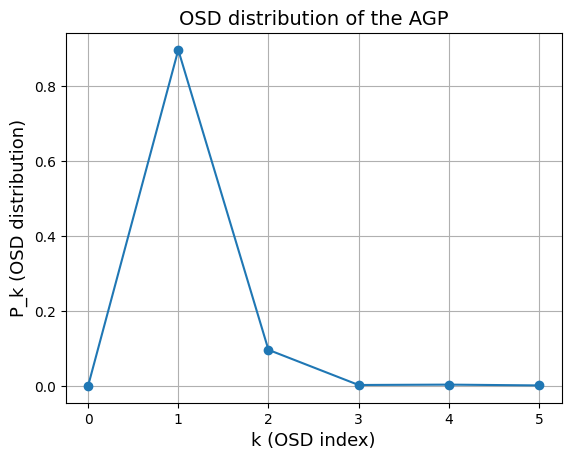

In [49]:
A = compute_exact_AGP(
    driver_hamiltonian, target_hamiltonian, lam=0.01
)  # your existing function
result = agp_osd(A, n=n_qubits)


print(result["P_k"])  # (n+1,) OSD
print(result["mean_size"])  # mu
for label, q, c in result["top_strings"]:
    print(f"{label}  q={q:.4f}  c={c:.4f}")

plt.plot(result["P_k"], marker="o")
plt.xlabel("k (OSD index)", fontsize=13)
plt.ylabel("P_k (OSD distribution)", fontsize=13)
plt.title("OSD distribution of the AGP", fontsize=14)
plt.grid()
plt.show()

Analysis over s

[4.07684196e-34 5.82102373e-04 6.84200414e-03 3.28592589e-02
 2.41468284e-01 7.18248350e-01]
4.669958776175957
YXXXX  q=0.0344  c=-1.6046+0.0000j
XYXXX  q=0.0344  c=-1.6046+0.0000j
XXYXX  q=0.0340  c=1.5938+0.0000j
XXXYX  q=0.0340  c=1.5938+0.0000j
XXXXY  q=0.0340  c=1.5938+0.0000j
YYXXY  q=0.0332  c=-1.5748+0.0000j
YYXYX  q=0.0332  c=-1.5748+0.0000j
YYYXX  q=0.0332  c=-1.5748+0.0000j
XYYYX  q=0.0327  c=1.5641+0.0000j
XYXYY  q=0.0327  c=1.5641+0.0000j


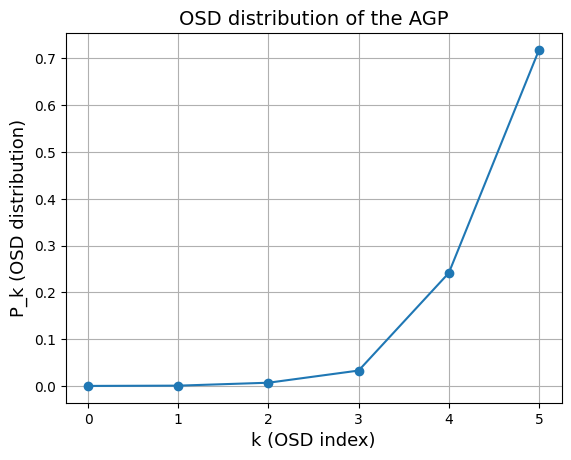

Computing AGP OSD for each s: 100%|██████████| 300/300 [00:15<00:00, 19.61it/s]


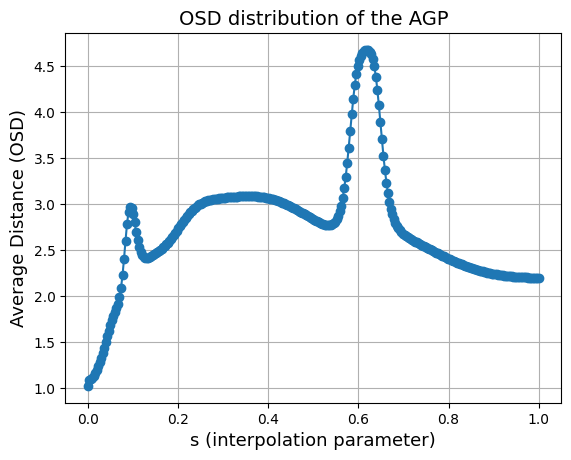

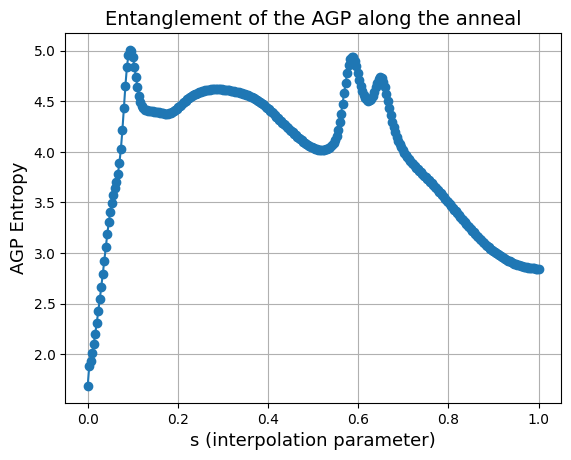

In [ ]:
from tqdm.asyncio import tqdm

avg_distance = []
agp_entropy = []
tbar = tqdm(s_vals, desc="Computing AGP OSD for each s")
for s in tbar:
    a_s = compute_exact_AGP(driver_hamiltonian, target_hamiltonian, lam=s)
    result = agp_osd(a_s, n=n_qubits)
    probs = result["probs"]
    avg_distance.append(result["mean_size"])
    agp_entropy.append(-np.sum(probs[probs > 0] * np.log(probs[probs > 0])))

plt.plot(s_vals, avg_distance, marker="o")
plt.xlabel("s", fontsize=13)
plt.ylabel("Average Distance (OSD)", fontsize=13)
plt.title("OSD distribution of the AGP", fontsize=14)
plt.grid()
plt.show()

plt.plot(s_vals, agp_entropy, marker="o")
plt.xlabel("s", fontsize=13)
plt.ylabel("AGP Entropy", fontsize=13)
plt.grid()
plt.show()

#### Stabilizer Renyi Entropy

In [44]:
from src.jax_utils import SREJax
from src.utils import EntanglementEntropy
from tqdm import trange

# build once — reuse for all states
sre = SREJax(n_qubits=nqubits)
entanglement_entropy = EntanglementEntropy(nqubits=nqubits, n_A=nqubits // 2)

# single state
magic = []
magic_gs_level = []
entanglement_entropy_gs_level_history = []
for i in trange(s_vals.shape[0]):
    state = psi_history[i]
    magic_gs_level.append(sre((state)))
    entanglement_entropy_gs_level_history.append(
        entanglement_entropy.von_neumann((state))
    )

Building Pauli index tables for n=5 (1,024 Paulis)...
Done.
Bipartition: A=2 qubits (4d), B=3 qubits (8d)


100%|██████████| 300/300 [00:00<00:00, 646.89it/s]


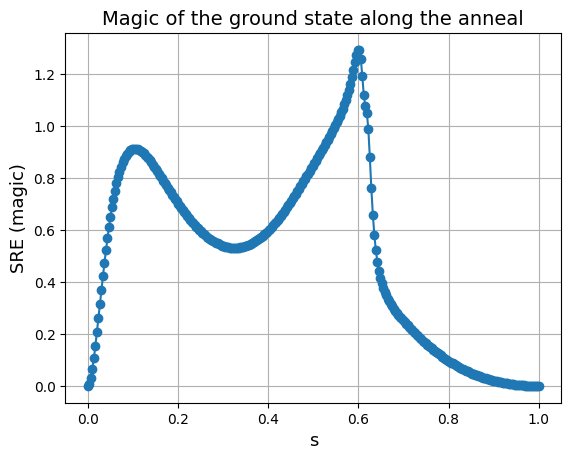

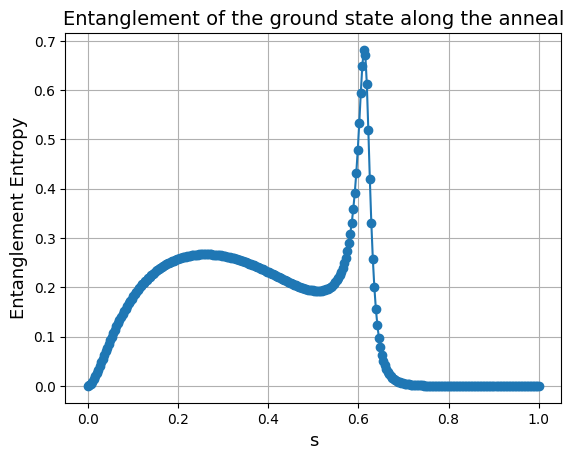

In [45]:
plt.plot(s_vals, magic_gs_level, marker="o")
plt.xlabel("s", fontsize=13)
plt.ylabel("SRE (magic)", fontsize=13)
plt.title("Magic of the ground state along the anneal", fontsize=14)
plt.grid()
plt.show()

plt.plot(s_vals, entanglement_entropy_gs_level_history, marker="o")
plt.xlabel("s", fontsize=13)
plt.ylabel("Entanglement Entropy", fontsize=13)
plt.title("Entanglement of the ground state along the anneal", fontsize=14)
plt.grid()
plt.show()